<h1 style="text-align:center;">Cooking Fuel Data Analysis</h1>

## Introduction

Retail cooking fuel industry often struggle with clear visibility into customer purchasing behavior, sales performance, and the effectiveness of marketing and discount strategies.

Without structured analysis, businesses risk:
- Losing customers without clear signals  
- Spending on discounts that do not generate returns  
- Missing early signs of declining demand  

This analysis covers three key layers:

1. **Descriptive analysis**  
   Focuses on what is happening in the data  

2. **Diagnostic analysis**  
   Explains why these patterns occur  

3. **Predictive analysis**  
   Estimates what is likely to happen next  

In [87]:
import pandas as pd

data = pd.read_csv("cooking_fuel.csv")

In [88]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1632 entries, 0 to 1631
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   transaction_id   1632 non-null   int64  
 1   customer_id      1632 non-null   int64  
 2   first_name       1632 non-null   object 
 3   last_name        1632 non-null   object 
 4   email            1632 non-null   object 
 5   state            1632 non-null   object 
 6   product_type     1632 non-null   object 
 7   size             1632 non-null   object 
 8   quantity         1632 non-null   int64  
 9   unit_price       1632 non-null   float64
 10  discount_amount  1632 non-null   float64
 11  total_amount     1632 non-null   float64
 12  collection_type  1632 non-null   object 
 13  sale_date        1632 non-null   object 
dtypes: float64(3), int64(3), object(8)
memory usage: 178.6+ KB


In [89]:
data["sale_date"] = pd.to_datetime(data["sale_date"])

In [90]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1632 entries, 0 to 1631
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   transaction_id   1632 non-null   int64         
 1   customer_id      1632 non-null   int64         
 2   first_name       1632 non-null   object        
 3   last_name        1632 non-null   object        
 4   email            1632 non-null   object        
 5   state            1632 non-null   object        
 6   product_type     1632 non-null   object        
 7   size             1632 non-null   object        
 8   quantity         1632 non-null   int64         
 9   unit_price       1632 non-null   float64       
 10  discount_amount  1632 non-null   float64       
 11  total_amount     1632 non-null   float64       
 12  collection_type  1632 non-null   object        
 13  sale_date        1632 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(3), int64(

In [91]:
data.head(10)

,transaction_id,customer_id,first_name,last_name,email,state,product_type,size,quantity,unit_price,discount_amount,total_amount,collection_type,sale_date
0,1800824,7844947,Brianna,Cook,bcook315@yahoo.com,Utah,AmeriGas,100lb,3,149.00,0.00,447.00,Pickup,2024-07-04
1,8921679,9712003,Ahmed,Harris,ahmedharris956@comcast.net,Utah,Blue Rhino,33lb,2,49.95,5.00,94.90,Pickup,2024-11-18
2,2697690,1485654,Patricia,Long,patricia_long@gmail.com.com,Tennessee,AmeriGas,20lb,4,24.99,0.00,99.96,Pickup,2024-07-18
3,7196363,5896624,Felix,Cox,fcox1042@comcast.net,Nevada,AmeriGas,420lb,4,849.00,339.60,3056.40,Delivery,2024-06-07
4,7103303,6170227,David,Patterson,david.patterson@hotmail.com,Louisiana,AmeriGas,100lb,3,149.00,0.00,447.00,Delivery,2024-06-24
5,1707302,8944327,Fatima,Cook,fcook@hotmail.com,Kansas,Blue Rhino,1lb,5,4.49,0.00,22.45,Delivery,2024-03-21
6,9788815,2525206,Jennifer,Young,jyoung@outlook.com,Tennessee,AmeriGas,33lb,5,49.95,0.00,249.75,Delivery,2024-01-18
7,3120605,6510922,Carlos,Webb,webb.c@yahoo.com,Texas,AmeriGas,100lb,1,149.00,0.00,149.00,Pickup,2024-12-15
8,4536127,2038068,Zoe,Perez,zoeperez1108@aol.com,Illinois,AmeriGas,33lb,2,49.95,7.99,91.91,Delivery,2024-04-25
9,1467937,7844947,Brianna,Cook,bcook315@@yahoo.com,Utah,NGL Energy,420lb,3,849.00,254.70,2292.30,Delivery,2024-05-10


In [92]:
data.duplicated().sum()

np.int64(0)

In [93]:
data.isna().sum()

transaction_id     0
customer_id        0
first_name         0
last_name          0
email              0
state              0
product_type       0
size               0
quantity           0
unit_price         0
discount_amount    0
total_amount       0
collection_type    0
sale_date          0
dtype: int64

In [94]:
data["name"] = data["first_name"].str.cat(data["last_name"], sep = " ")

In [95]:
data.head()

,transaction_id,customer_id,first_name,last_name,email,state,product_type,size,quantity,unit_price,discount_amount,total_amount,collection_type,sale_date,name
0,1800824,7844947,Brianna,Cook,bcook315@yahoo.com,Utah,AmeriGas,100lb,3,149.00,0.0,447.00,Pickup,2024-07-04,Brianna Cook
1,8921679,9712003,Ahmed,Harris,ahmedharris956@comcast.net,Utah,Blue Rhino,33lb,2,49.95,5.0,94.90,Pickup,2024-11-18,Ahmed Harris
2,2697690,1485654,Patricia,Long,patricia_long@gmail.com.com,Tennessee,AmeriGas,20lb,4,24.99,0.0,99.96,Pickup,2024-07-18,Patricia Long
3,7196363,5896624,Felix,Cox,fcox1042@comcast.net,Nevada,AmeriGas,420lb,4,849.00,339.6,3056.40,Delivery,2024-06-07,Felix Cox
4,7103303,6170227,David,Patterson,david.patterson@hotmail.com,Louisiana,AmeriGas,100lb,3,149.00,0.0,447.00,Delivery,2024-06-24,David Patterson


In [96]:
data.drop(columns = ["first_name", "last_name"])

,transaction_id,customer_id,email,state,product_type,size,quantity,unit_price,discount_amount,total_amount,collection_type,sale_date,name
0,1800824,7844947,bcook315@yahoo.com,Utah,AmeriGas,100lb,3,149.00,0.00,447.00,Pickup,2024-07-04,Brianna Cook
1,8921679,9712003,ahmedharris956@comcast.net,Utah,Blue Rhino,33lb,2,49.95,5.00,94.90,Pickup,2024-11-18,Ahmed Harris
2,2697690,1485654,patricia_long@gmail.com.com,Tennessee,AmeriGas,20lb,4,24.99,0.00,99.96,Pickup,2024-07-18,Patricia Long
3,7196363,5896624,fcox1042@comcast.net,Nevada,AmeriGas,420lb,4,849.00,339.60,3056.40,Delivery,2024-06-07,Felix Cox
4,7103303,6170227,david.patterson@hotmail.com,Louisiana,AmeriGas,100lb,3,149.00,0.00,447.00,Delivery,2024-06-24,David Patterson
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1627,6741177,1098919,gray.h@comcast.net,Wisconsin,NGL Energy,20lb,2,24.99,0.00,49.98,Pickup,2024-03-26,Hiroshi Gray
1628,2316088,6204824,rajscott709@live.com,Colorado,AmeriGas,20lb,5,24.99,0.00,124.95,Delivery,2024-05-24,Raj Scott
1629,8624921,3508522,paulowashington1664@comcast.net,Georgia,Suburban Propane,20lb,4,24.99,0.00,99.96,Pickup,2024-02-10,Paulo Washington
1630,8591832,7268384,sanjay.v32@sbcglobal.net,Massachusetts,Ferrellgas,420lb,3,849.00,305.64,2241.36,Delivery,2024-05-14,Sanjay Vasquez


In [97]:
col = data.pop("name")
data.insert(2, "name", col)


In [98]:
data = data.drop(columns = ["first_name","last_name"])

In [99]:
data.head(2)

,transaction_id,customer_id,name,email,state,product_type,size,quantity,unit_price,discount_amount,total_amount,collection_type,sale_date
0,1800824,7844947,Brianna Cook,bcook315@yahoo.com,Utah,AmeriGas,100lb,3,149.00,0.0,447.0,Pickup,2024-07-04
1,8921679,9712003,Ahmed Harris,ahmedharris956@comcast.net,Utah,Blue Rhino,33lb,2,49.95,5.0,94.9,Pickup,2024-11-18


In [100]:
valid_email   = data["email"].str.match(r"^[\w.-]+@[\w.-]+\.\w+$", na=False)
invalid_df    = data[~valid_email]

bad_customer_ids  = set(invalid_df["customer_id"])
good_customer_ids = set(data[valid_email]["customer_id"])

recoverable   = bad_customer_ids & good_customer_ids
unrecoverable = bad_customer_ids - good_customer_ids

print(f"Recoverable:   {len(recoverable)}")
print(f"Unrecoverable: {len(unrecoverable)}")

Recoverable:   44
Unrecoverable: 0


In [101]:
valid_email = data["email"].str.match(r"^[\w.-]+@[\w.-]+\.\w+$",na = False)


In [102]:
data[~valid_email].shape

(50, 13)

In [103]:
data[~valid_email].head()

,transaction_id,customer_id,name,email,state,product_type,size,quantity,unit_price,discount_amount,total_amount,collection_type,sale_date
9,1467937,7844947,Brianna Cook,bcook315@@yahoo.com,Utah,NGL Energy,420lb,3,849.00,254.7,2292.30,Delivery,2024-05-10
30,9249791,2338687,Irina Walker,irina_walker@comcast,Utah,Suburban Propane,100lb,4,149.00,89.4,506.60,Pickup,2024-06-04
67,7656588,4052834,Ana Wallace,ana.wallace@attnet,Missouri,Ferrellgas,1lb,5,4.49,0.0,22.45,Delivery,2024-06-06
109,8431976,9302946,Antoine Watson,antoine.watson@@att.net,Tennessee,AmeriGas,20lb,4,24.99,0.0,99.96,Pickup,2024-02-11
120,3284720,2893218,Thomas Gonzalez,thomas.gonzalez@live,Florida,Blue Rhino,1lb,4,4.49,0.0,17.96,Pickup,2024-09-05


In [104]:
customer_valid_emails = (data[valid_email].sort_values("customer_id").drop_duplicates(subset="customer_id", keep="first")
    [["customer_id", "email"]]
)

In [105]:
data = ( data.drop(columns=["email"]).merge(customer_valid_emails, on="customer_id", how="left"))

In [106]:
data[~valid_email].shape

(50, 13)

#### Data Quality Assessment

After reviewing the dataset, several data quality observations were identified. The dataset contains no missing values, which supports completeness and reduces the need for imputation. However, the `sale_date` column was stored as a string, indicating an incorrect data type that may affect time-based analysis. In addition, invalid email entries were detected, which suggests a lack of real-time validation during data collection.

To improve data reliability, the business should enforce proper datetime formatting within the data pipeline to ensure accurate temporal analysis. It should also implement real-time email validation at the point of data entry to prevent invalid records from entering the system.

### 1. Descriptive Analysis

We start by identifying trends in monthly sales.

In [107]:
data["transaction_id"].nunique()

1632

##### *Order Validation*  
I first checked the `transaction_id` column to confirm if it represents orders. The column contains 1,632 unique values, which matches the total number of rows in the dataset. This confirms each row represents a unique transaction. Therefore, `transaction_id` is a reliable measure of total orders.

In [108]:
data["month"] = data["sale_date"].dt.strftime("%b")

In [109]:
data.head(3)

,transaction_id,customer_id,name,state,product_type,size,quantity,unit_price,discount_amount,total_amount,collection_type,sale_date,email,month
0,1800824,7844947,Brianna Cook,Utah,AmeriGas,100lb,3,149.00,0.0,447.00,Pickup,2024-07-04,bcook315@yahoo.com,Jul
1,8921679,9712003,Ahmed Harris,Utah,Blue Rhino,33lb,2,49.95,5.0,94.90,Pickup,2024-11-18,ahmedharris956@comcast.net,Nov
2,2697690,1485654,Patricia Long,Tennessee,AmeriGas,20lb,4,24.99,0.0,99.96,Pickup,2024-07-18,patricia_long@gmail.com,Jul


In [110]:
month_order = ["Jan","Feb","Mar","Apr","May","Jun",
         "Jul","Aug","Sep","Oct","Nov","Dec"]

In [111]:
sales = data.groupby("month")["transaction_id"].count().reindex(month_order)
print(sales)

month
Jan    136
Feb    174
Mar    123
Apr    155
May    144
Jun    146
Jul    155
Aug    143
Sep    128
Oct    134
Nov     94
Dec    100
Name: transaction_id, dtype: int64


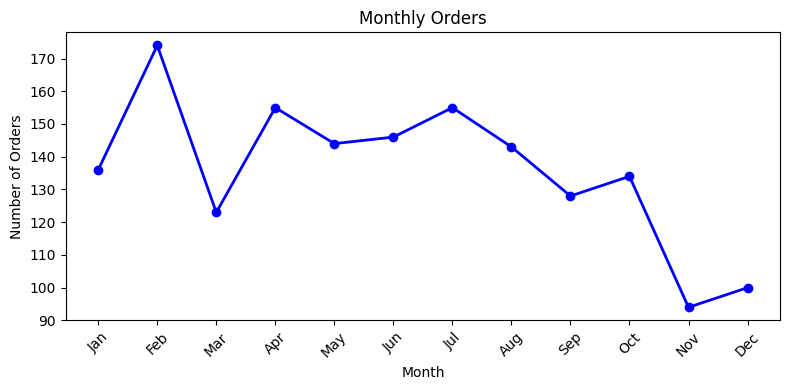

In [112]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 4))
plt.plot(sales.index, sales.values, marker="o", color="blue", linewidth=2)


plt.title("Monthly Orders")
plt.xlabel("Month")
plt.ylabel("Number of Orders")


plt.xticks(rotation=45)  
plt.tight_layout()        
plt.show()

From the chart we can see that February records the highest number of orders which is **174** while November has the least number of orders of **94**. Orders recover in April and remain fairly stable through July, ranging between **144** and **155**. This period shows consistent performance with moderate fluctuations.

From August, orders begin to decline. September and October continue at lower levels compared to mid year.

November shows the lowest orders, around **94**. This is a significant drop and stands out as the weakest month while December shows a slight recovery but remains low compared to most months.

This pattern suggests strong early demand, stable middle performance, and weak sales toward the end of the year.

In [113]:
state_sales = data.groupby("state")["transaction_id"].count().sort_values(ascending = False)
state_sales.head(10)

state
Georgia           86
North Carolina    84
Tennessee         78
Utah              69
Massachusetts     68
Oklahoma          66
New York          64
Ohio              63
Louisiana         62
Florida           62
Name: transaction_id, dtype: int64

In [114]:
state_sales.tail(10)

state
Colorado        47
Pennsylvania    44
Wisconsin       43
California      40
Indiana         40
Arizona         38
Texas           37
Oregon          34
Washington      32
Virginia        25
Name: transaction_id, dtype: int64

In [115]:
top_10 =state_sales.head(10)
bottom_10 = state_sales.tail(10)

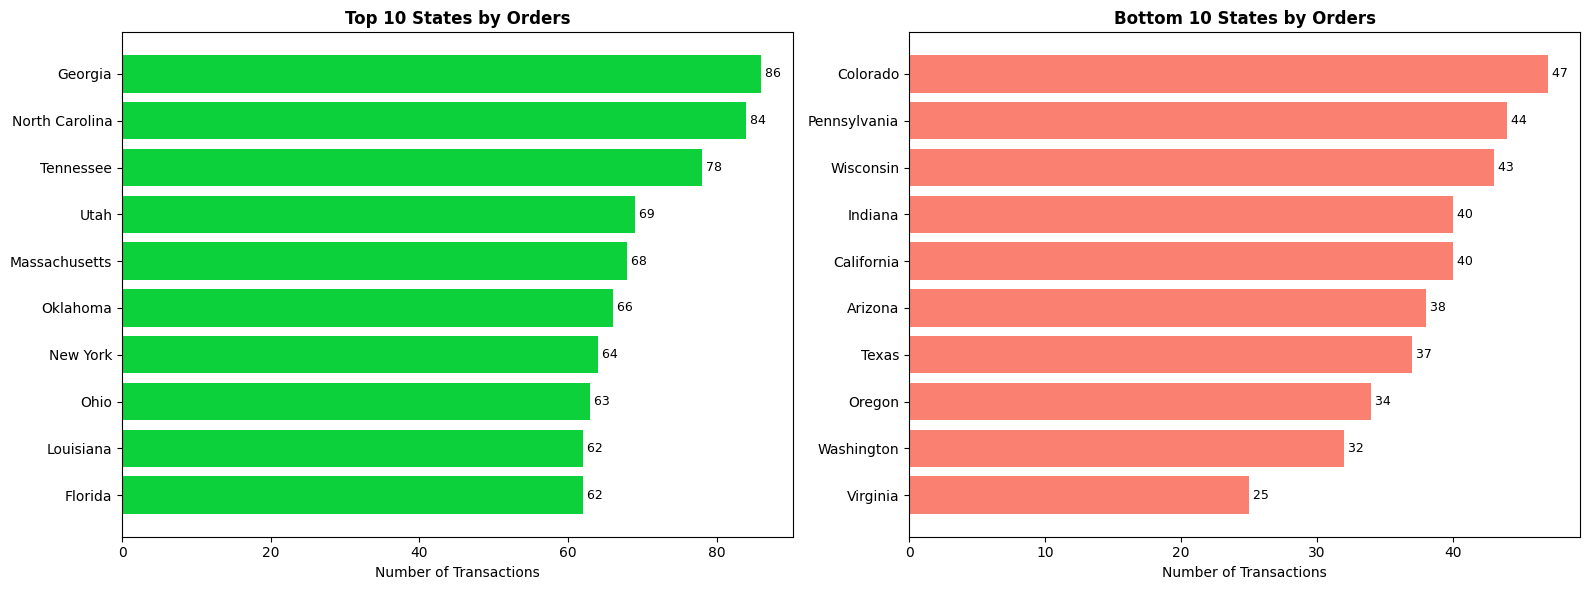

In [116]:
top_10 = top_10.sort_values(ascending=True)
bottom_10 = bottom_10.sort_values(ascending=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

bars1 = ax1.barh(top_10.index, top_10.values, color="#0DD13A")
ax1.set_title("Top 10 States by Orders", fontweight="bold")
ax1.set_xlabel("Number of Transactions")

for bar in bars1:
    width = bar.get_width()
    ax1.text(width, bar.get_y() + bar.get_height() / 2,
             f" {int(width)}",
             va="center", ha="left",
             fontsize=9, color="black")

bars2 = ax2.barh(bottom_10.index, bottom_10.values, color="salmon")
ax2.set_title("Bottom 10 States by Orders", fontweight="bold")
ax2.set_xlabel("Number of Transactions")

for bar in bars2:
    width = bar.get_width()
    ax2.text(width, bar.get_y() + bar.get_height() / 2,
             f" {int(width)}",
             va="center", ha="left",
             fontsize=9, color="black")

plt.tight_layout()
plt.show()

Top performing states show strong order volumes. Georgia leads with **86** orders. North Carolina follows with **84**. Tennessee comes next with **78**. These states stand out as the main drivers of sales.

The rest of the top group stays within a close range, from about **62** to **69**. This shows stable performance among the top 10, with no extreme gaps after the top three.

Bottom performing states show much lower activity. Colorado leads this group with **47**, which is still far below the top states. Pennsylvania and Wisconsin follow with **44** and **43**. The weakest state is Virginia with only **25** transactions. This is less than one third of Georgia’s volume, showing a large performance gap.

This pattern shows uneven orders distribution, where a few states generate most of the orders while others contribute much less.

In [117]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1632 entries, 0 to 1631
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   transaction_id   1632 non-null   int64         
 1   customer_id      1632 non-null   int64         
 2   name             1632 non-null   object        
 3   state            1632 non-null   object        
 4   product_type     1632 non-null   object        
 5   size             1632 non-null   object        
 6   quantity         1632 non-null   int64         
 7   unit_price       1632 non-null   float64       
 8   discount_amount  1632 non-null   float64       
 9   total_amount     1632 non-null   float64       
 10  collection_type  1632 non-null   object        
 11  sale_date        1632 non-null   datetime64[ns]
 12  email            1632 non-null   object        
 13  month            1632 non-null   object        
dtypes: datetime64[ns](1), float64(3), int64(

In [118]:
first_purchase  = data.sort_values("sale_date").drop_duplicates("customer_id")


In [119]:
first_purchase.drop(columns = ["month"])

,transaction_id,customer_id,name,state,product_type,size,quantity,unit_price,discount_amount,total_amount,collection_type,sale_date,email
420,1157641,8608449,Amit Kim,Massachusetts,AmeriGas,420lb,3,849.00,0.00,2547.00,Pickup,2024-01-01,amit41@yahoo.com
1152,5102892,7455324,Hana Stevens,Massachusetts,AmeriGas,100lb,3,149.00,0.00,447.00,Pickup,2024-01-01,hana_stevens@att.net
59,9213276,8115687,Bjorn Fisher,Ohio,Blue Rhino,100lb,3,149.00,67.05,379.95,Pickup,2024-01-01,bjorn.f45@icloud.com
672,1142206,2374158,Antoine Garcia,New Mexico,AmeriGas,1lb,4,4.49,0.90,17.06,Delivery,2024-01-01,antoine.garcia@att.net
1382,1109275,4431161,Priya Cooper,Colorado,NGL Energy,100lb,5,149.00,0.00,745.00,Delivery,2024-01-01,priya37@att.net
...,...,...,...,...,...,...,...,...,...,...,...,...,...
817,8297709,7907400,Aisha Ward,Oklahoma,NGL Energy,420lb,3,849.00,0.00,2547.00,Delivery,2024-06-12,aishaward858@outlook.com
563,3347640,5675638,Aisha Allen,Colorado,Suburban Propane,33lb,1,49.95,0.00,49.95,Pickup,2024-06-29,aallen@gmail.com
527,1903041,3592974,Mohammed Mitchell,Wisconsin,AmeriGas,100lb,5,149.00,0.00,745.00,Pickup,2024-07-01,mitchell.m@outlook.com
234,1979271,9988193,Siobhan Garcia,New York,Ferrellgas,420lb,5,849.00,0.00,4245.00,Delivery,2024-07-09,garcia.s@att.net


In [120]:
first_purchase["month"] = first_purchase["sale_date"].dt.strftime("%b")

In [121]:
monthg = first_purchase.groupby("month")["customer_id"].count().reindex(month_order).fillna(0).astype(int)
print(monthg)

month
Jan    134
Feb    129
Mar      9
Apr     10
May      7
Jun      5
Jul      2
Aug      0
Sep      1
Oct      0
Nov      0
Dec      0
Name: customer_id, dtype: int64


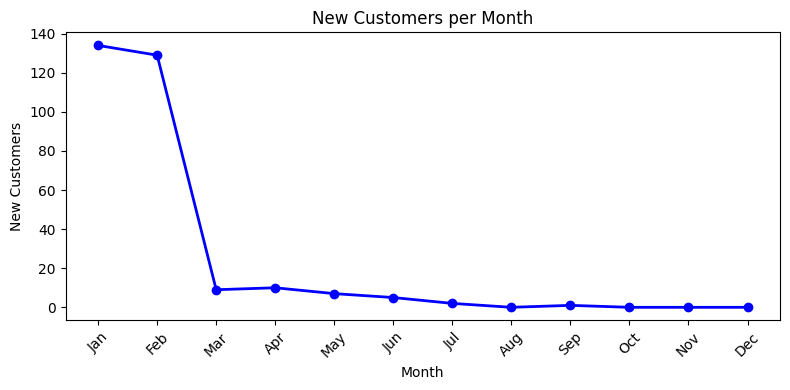

In [122]:
plt.figure(figsize=(8, 4))
plt.plot(monthg.index, monthg.values, marker="o", color="blue", linewidth=2)

plt.title("New Customers per Month")
plt.xlabel("Month")
plt.ylabel("New Customers")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

New customers are heavily concentrated at the start of the year. January records **134** new customers, followed closely by February with **129**. These two months account for nearly all customer acquisition.

From March, numbers drop sharply with only **9** new customers in March, **10** in April, and **7** in May.

The decline continues through June and July, with very low counts throughout. From August onward, acquisition nearly stops entirely. Several months record zero new customers, with only **1** recorded in September.

This pattern shows strong early growth but weak customer acquisition for the rest of the year.

In [123]:
data["product_type"].unique().tolist()

['AmeriGas', 'Blue Rhino', 'NGL Energy', 'Ferrellgas', 'Suburban Propane']

In [124]:
product_sales = data.groupby("product_type")["transaction_id"].count().sort_values()
product_revenue = data.groupby("product_type")["total_amount"].sum().sort_values()

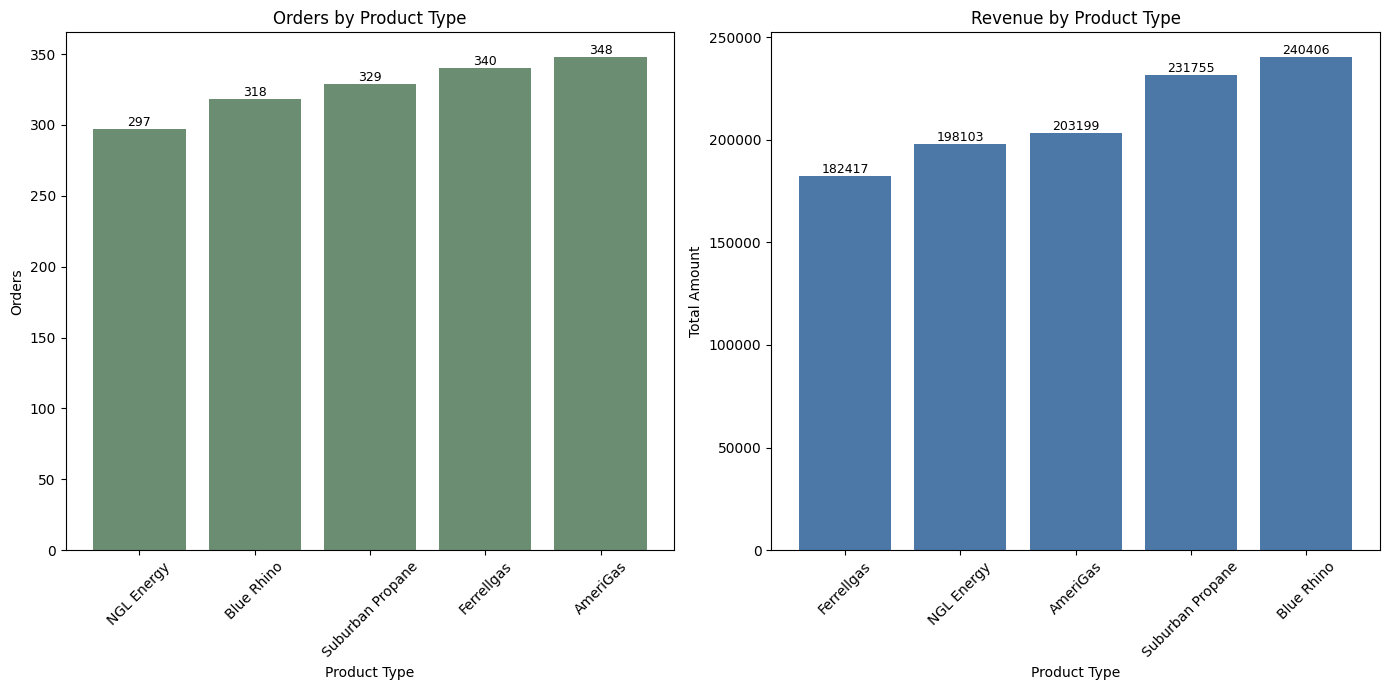

In [125]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))

bars1 = ax1.bar(product_sales.index, product_sales.values, color="#6B8E73")
ax1.set_title("Orders by Product Type")
ax1.set_xlabel("Product Type")
ax1.set_ylabel("Orders")
ax1.tick_params(axis="x", rotation=45)

for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, height,
             f"{int(height)}",
             ha="center", va="bottom", fontsize=9)

bars2 = ax2.bar(product_revenue.index, product_revenue.values, color="#4C78A8")
ax2.set_title("Revenue by Product Type")
ax2.set_xlabel("Product Type")
ax2.set_ylabel("Total Amount")
ax2.tick_params(axis="x", rotation=45)

for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, height,
             f"{height:.0f}",
             ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

AmeriGas has the highest number of orders at **348**, while NGL Energy has the lowest at **297**. The difference between the highest and lowest is small, showing that order volumes are fairly balanced across product types.

In terms of revenue, Blue Rhino generates the highest total revenue at \$**240406.47**, followed by Suburban Propane. Ferrellgas has the lowest revenue even though it records one of the higher transaction counts.

### **2. Diagnostic Analysis**

In this section, the focus is on understanding the reasons behind the patterns seen in the data. It goes beyond describing what happened and explains why it happened. The goal is to connect changes in key metrics such as sales, customers, discounts, or revenue to possible causes like pricing, product performance, or customer behavior.

I will start by analyzing what drives sales since I observed that sales fluctuate as the months increase. I will break down the data step by step to identify the key factors behind these changes. This includes examining trends in discounts to understand what is influencing sales over time. The goal is to clearly identify the reasons for the fluctuations and determine which factors have the strongest impact on sales.

In [126]:
monthly_sales = data.groupby("month")["transaction_id"].count().reindex(month_order)
print(monthly_sales)

month
Jan    136
Feb    174
Mar    123
Apr    155
May    144
Jun    146
Jul    155
Aug    143
Sep    128
Oct    134
Nov     94
Dec    100
Name: transaction_id, dtype: int64


To investigate the year-end orders decline, I checked the collection type across all months. As seen in the chart, both Delivery and Pickup mirror each other throughout the year, peaking together during high months such as February (**85** Delivery, **89** Pickup) and July (**68** Delivery, **87** Pickup), and dropping during slower periods.

At no point does one channel rise to compensate for the other's weakness, ruling out a shift in customer collection preference. This indicates that collection type is not the root cause of the sales decline. It suggests that collection type is not driving the year-end drop in sales.

In [127]:
collection_monthly = data.groupby(["month", "collection_type"])["transaction_id"].count().unstack()
collection_monthly = collection_monthly.reindex(month_order)
print(collection_monthly)

collection_type  Delivery  Pickup
month                            
Jan                    74      62
Feb                    85      89
Mar                    64      59
Apr                    87      68
May                    73      71
Jun                    70      76
Jul                    68      87
Aug                    75      68
Sep                    63      65
Oct                    64      70
Nov                    54      40
Dec                    46      54


<Figure size 800x400 with 0 Axes>

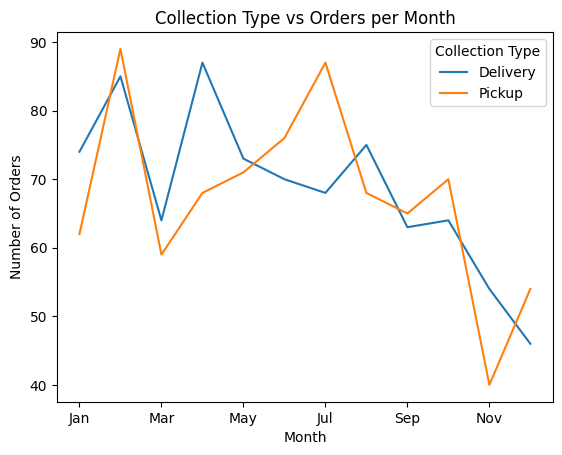

In [128]:
plt.figure(figsize=(8, 4))

collection_monthly.plot()

plt.title("Collection Type vs Orders per Month")
plt.xlabel("Month")
plt.ylabel("Number of Orders")

plt.legend(title="Collection Type")

plt.show()

I then reviewed the product size across all months. As seen in the chart, prices remained completely consistent throughout the year across all five size categories, with no variation observed from January through December. This confirms that pricing was stable and did not influence customer purchasing behaviour at any point during the year.

In [129]:
size_price_monthly = data.groupby(["month", "size"])["unit_price"].mean().unstack()
print(size_price_monthly)

size   100lb   1lb   20lb   33lb  420lb
month                                  
Apr    149.0  4.49  24.99  49.95  849.0
Aug    149.0  4.49  24.99  49.95  849.0
Dec    149.0  4.49  24.99  49.95  849.0
Feb    149.0  4.49  24.99  49.95  849.0
Jan    149.0  4.49  24.99  49.95  849.0
Jul    149.0  4.49  24.99  49.95  849.0
Jun    149.0  4.49  24.99  49.95  849.0
Mar    149.0  4.49  24.99  49.95  849.0
May    149.0  4.49  24.99  49.95  849.0
Nov    149.0  4.49  24.99  49.95  849.0
Oct    149.0  4.49  24.99  49.95  849.0
Sep    149.0  4.49  24.99  49.95  849.0


<function matplotlib.pyplot.show(close=None, block=None)>

<Figure size 800x400 with 0 Axes>

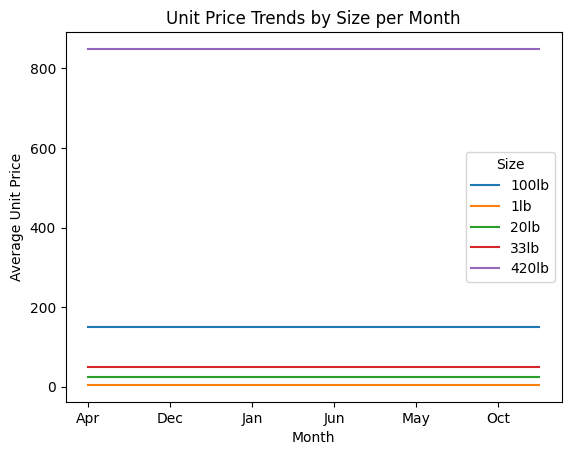

In [130]:
plt.figure(figsize=(8, 4))

size_price_monthly.plot()

plt.title("Unit Price Trends by Size per Month")
plt.xlabel("Month")
plt.ylabel("Average Unit Price")

plt.legend(title="Size")

plt.show

Discount orders and total orders appear to move together throughout the year. When discount orders rise, total orders follow, and when discount orders fall, total orders also decline. This parallel movement, as seen in the chart, suggests a possible relationship between discounts and sales volume.

For instance, both lines peak around February and July and both drop sharply towards November and December. While the relationship between discount orders and total orders looks closely linked, it would be premature to conclude that discounts are the root cause of the sales trend.

Further analysis will be carried out to confirm whether discounts are genuinely driving customer purchases or whether both are responding to the same underlying seasonal pattern.

In [131]:
discount_count = data[data["discount_amount"] > 0]


In [132]:
monthly_discount_count= discount_count.groupby("month")["discount_amount"].count().reindex(month_order)
print(monthly_discount_count)

month
Jan    50
Feb    62
Mar    26
Apr    39
May    43
Jun    52
Jul    51
Aug    47
Sep    25
Oct    28
Nov    23
Dec    30
Name: discount_amount, dtype: int64


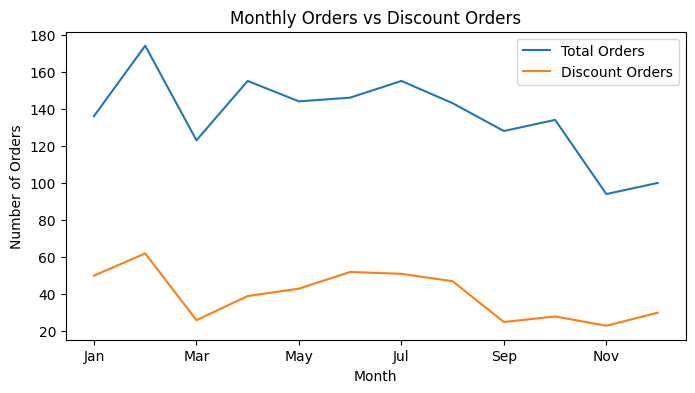

In [133]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 4))
monthly_sales.plot()
monthly_discount_count.plot()

plt.title("Monthly Orders vs Discount Orders")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.legend(["Total Orders", "Discount Orders"])
plt.show()

To confirm whether discounts were genuinely driving customer purchases, the average quantity and average revenue were compared between discounted and non-discounted orders.

The results were remarkably close. Discounted orders averaged **2.94** units per transaction while non-discounted orders averaged **2.98** units, a negligible difference of **0.04** units. Similarly, average revenue per transaction was almost identical, with discounted orders generating \$**646.43** against \$**647.21** for non-discounted orders, a difference of less than \$**1.00**.

These findings confirm that discounts have no impact on how much customers buy or how much they spend per transaction. Customers purchase the same quantity and spend the same amount regardless of whether a discount is applied, ruling out discounts as a driver of sales volume.

The similar movement observed earlier between discount orders and total orders therefore reflects a shared seasonal pattern rather than discounts actively driving orders. Other factors will be explored to identify the true driver of the year-end decline.

In [134]:
discount_orders = data[data["discount_amount"] > 0]
no_discount_orders = data[data["discount_amount"] == 0]

In [135]:
avg_discount_orders_quantity = discount_orders["quantity"].mean()
avg_no_discount_orders_quantity = no_discount_orders["quantity"].mean()
print(avg_discount_orders_quantity)
print(avg_no_discount_orders_quantity)

2.94327731092437
2.9775086505190314


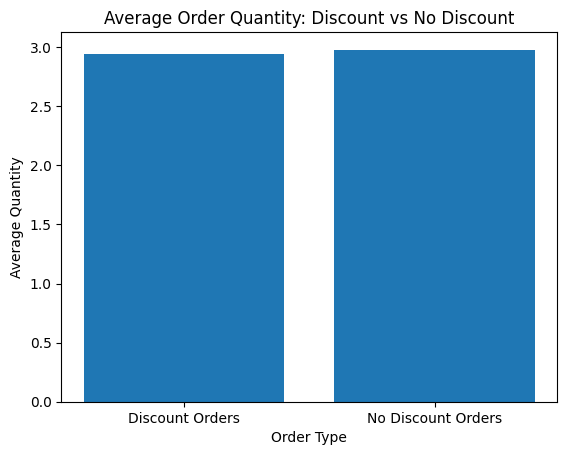

In [136]:
labels = ["Discount Orders", "No Discount Orders"]
values = [avg_discount_orders_quantity, avg_no_discount_orders_quantity]

# Plot
plt.figure()
plt.bar(labels, values)

# Labels and title
plt.xlabel("Order Type")
plt.ylabel("Average Quantity")
plt.title("Average Order Quantity: Discount vs No Discount")

plt.show()

In [137]:
avg_discount_orders_revenue = discount_orders["total_amount"].mean()
avg_no_discount_orders_revenue = no_discount_orders["total_amount"].mean()
print(avg_discount_orders_revenue)
print(avg_no_discount_orders_revenue)

646.4324789915966
647.2135467128027


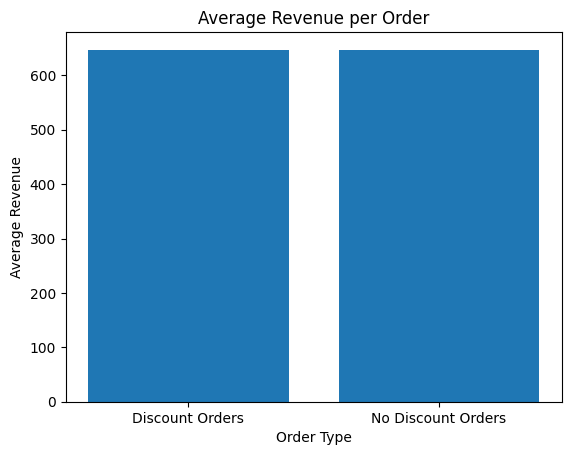

In [138]:
plt.figure()
plt.bar(
    ["Discount Orders", "No Discount Orders"],
    [avg_discount_orders_revenue, avg_no_discount_orders_revenue]
)

plt.xlabel("Order Type")
plt.ylabel("Average Revenue")
plt.title("Average Revenue per Order")

plt.show()

In [139]:
print(data.groupby("customer_id")["discount_amount"].sum().describe())


count     297.000000
mean      112.066667
std       186.969171
min         0.000000
25%         0.000000
50%        17.980000
75%       138.090000
max      1027.290000
Name: discount_amount, dtype: float64


In [140]:
total_revenue   = data["total_amount"].sum()
total_discount  = data["discount_amount"].sum()
discount_pct    = (total_discount / total_revenue * 100).round(2)

print("=" * 45)
print("  REVENUE & DISCOUNT SUMMARY")
print("=" * 45)
print(f"  Total Revenue          : ${total_revenue:,.2f}")
print(f"  Total Discount Given   : ${total_discount:,.2f}")
print(f"  Discount % of Revenue  : {discount_pct}%")
print("=" * 45)

  REVENUE & DISCOUNT SUMMARY
  Total Revenue          : $1,055,880.72
  Total Discount Given   : $33,283.80
  Discount % of Revenue  : 3.15%


I analyzed new customer acquisition alongside discounted new customers across the year. As seen in the chart, new customers were predominantly acquired in January and February, with both new and discounted new customers dropping sharply from March onwards and effectively reaching zero by August. This shows that the business stopped acquiring new customers almost entirely from the second quarter of the year, meaning that sales from March through December were sustained mainly by existing repeat customers.

The absence of new customer acquisition from mid-year onwards is a major factor in the year-end sales decline. While a mild seasonal effect cannot be completely ruled out, its impact appears minimal. The core issue is heavy reliance on the existing customer base with no inflow of new customers, which caused overall sales volumes to weaken towards the end of the year.

The findings show that the decline in year-end sales was primarily driven by the lack of new customer acquisition. The business depended on its existing customers to sustain sales throughout the year, with almost no new customers entering from March onwards. This is a key area for improvement to support consistent sales growth across all months.

The company also offered discounts without a clear structure or strategy. Earlier analysis showed that discounts had no meaningful impact on quantity purchased or revenue generated per transaction. Despite this, the business gave away \$**33,283.80** in discounts, representing **3.15%** of total revenue of \$**1,055,880.72**, without measurable improvement in customer behavior or orders uplift. This reflects unnecessary cost leakage that reduced profitability without delivering a sales advantage.

In [141]:
df = data.sort_values("sale_date").copy()

In [142]:
first_purchase = df.groupby("customer_id").first().reset_index()
first_purchase["month"] = first_purchase["sale_date"].dt.strftime("%b") 

In [143]:
monthly_new_customers = first_purchase.groupby("month")["customer_id"].nunique()
monthly_new_discount_customers = first_purchase[first_purchase["discount_amount"] > 0].groupby("month")["customer_id"].nunique()

In [144]:
monthly_new_customers = monthly_new_customers.reindex(month_order)
monthly_new_discount_customers = monthly_new_discount_customers.reindex(month_order)

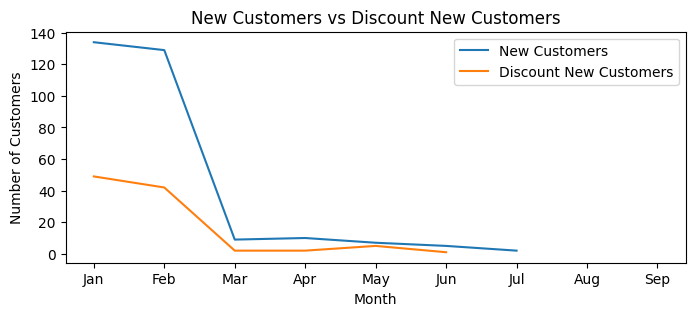

In [145]:
plt.figure(figsize=(8, 3))

monthly_new_customers.plot()
monthly_new_discount_customers.plot()

plt.title("New Customers vs Discount New Customers")
plt.xlabel("Month")
plt.ylabel("Number of Customers")
plt.legend(["New Customers", "Discount New Customers"])

plt.show()

In [146]:
monthly_table = pd.DataFrame({
    "New Customers": monthly_new_customers,
    "Discount New Customers": monthly_new_discount_customers
})

monthly_table = monthly_table.fillna(0).astype(int)

print(monthly_table)

       New Customers  Discount New Customers
month                                       
Jan              134                      49
Feb              129                      42
Mar                9                       2
Apr               10                       2
May                7                       5
Jun                5                       1
Jul                2                       0
Aug                0                       0
Sep                1                       0
Oct                0                       0
Nov                0                       0
Dec                0                       0


### **3. Predictive Analysis**
Having established a clear picture of business performance through descriptive and diagnostic analysis, the focus now shifts to predictive analysis. This section examines individual customer purchasing behaviour by analyzing purchase cycles and day gaps between transactions. By understanding how frequently each customer buys and how consistent their patterns are, the business can estimate when each customer is likely to make their next purchase.

These insights enable the company to take proactive actions such as sending targeted marketing emails before a customer is due to return, grouping customers into meaningful segments based on buying behaviour, and identifying customers who are at risk of churning before they are lost. The goal is to move the business from reacting to past sales to predicting and influencing future sales.

In [147]:
reference_date = df['sale_date'].max()
print(reference_date)

2024-12-31 00:00:00


In [148]:
customer_df = df.groupby('customer_id').agg(
    name=('name', 'first'),
    email=('email', 'first'),
    first_purchase=('sale_date', 'min'),
    last_purchase=('sale_date', 'max'),
    frequency=('transaction_id', 'count'),
    total_spent=('total_amount', 'sum')
).reset_index()

In [149]:
customer_df.head()

,customer_id,name,email,first_purchase,last_purchase,frequency,total_spent
0,1044891,Vikram Chavez,vchavez671@live.com,2024-02-22,2024-10-30,6,1565.02
1,1047572,Patrick Nelson,patrick_nelson@outlook.com,2024-05-10,2024-08-01,2,425.37
2,1098919,Hiroshi Gray,gray.h@comcast.net,2024-01-31,2024-12-21,6,3104.61
3,1157662,Olivia Watson,owatson@att.net,2024-01-08,2024-01-08,1,20.65
4,1279121,Takeshi Foster,foster.t@yahoo.com,2024-02-20,2024-02-20,1,1698.00


In [150]:
df_sorted = df.sort_values(['customer_id', 'sale_date'])
df_sorted['prev_date'] = df_sorted.groupby('customer_id')['sale_date'].shift(1)
df_sorted['gap_days'] = (df_sorted['sale_date'] - df_sorted['prev_date']).dt.days

In [151]:
customer_median_gap = df_sorted.groupby('customer_id')['gap_days'].median().reset_index()
customer_median_gap.columns = ['customer_id', 'median_gap_days']

In [152]:
global_median = customer_median_gap['median_gap_days'].median()
print(f"Global median gap: {global_median} days")

Global median gap: 57.0 days


In [153]:
customer_df = customer_df.merge(customer_median_gap, on='customer_id', how='left')

In [154]:
customer_df['median_gap_days'] = customer_df['median_gap_days'].fillna(global_median)

In [155]:
print(f"Global median: {global_median}")
print(customer_df[['customer_id', 'frequency', 'median_gap_days']].head(10))

Global median: 57.0
   customer_id  frequency  median_gap_days
0      1044891          6             51.0
1      1047572          2             83.0
2      1098919          6             55.0
3      1157662          1             57.0
4      1279121          1             57.0
5      1432519         13             24.5
6      1440972          3             88.0
7      1447065          2            107.0
8      1447451          7             51.0
9      1454696          6             58.0


In [156]:
customer_df['current_gap_days'] = (reference_date - customer_df['last_purchase']).dt.days

In [157]:
print(f"Reference date: {reference_date}")
print(customer_df[['customer_id', 'frequency', 'median_gap_days', 'current_gap_days']].head(10))

Reference date: 2024-12-31 00:00:00
   customer_id  frequency  median_gap_days  current_gap_days
0      1044891          6             51.0                62
1      1047572          2             83.0               152
2      1098919          6             55.0                10
3      1157662          1             57.0               358
4      1279121          1             57.0               315
5      1432519         13             24.5                16
6      1440972          3             88.0               135
7      1447065          2            107.0                99
8      1447451          7             51.0                10
9      1454696          6             58.0                53


In [158]:
def classify_customer(row):
    gap = row['current_gap_days']
    cycle = row['median_gap_days']

    if row['frequency'] == 1:
        if gap <= cycle:
            return 'new customer'        # just bought once, still within expected window
        elif gap <= cycle * 2:
            return 'one-time - at risk'  # window passing, never returned
        else:
            return 'one-time - churned'  # gone way too long

    if gap <= cycle:
        return 'active'                  # buying on schedule
    elif gap <= cycle * 1.5:
        return 'due soon'                # slightly overdue, warm nudge
    elif gap <= cycle * 2:
        return 'at risk'                 # clearly overdue
    else:
        return 'churned'                

customer_df['status'] = customer_df.apply(classify_customer, axis=1)

In [159]:
print(customer_df[['customer_id', 'frequency', 'median_gap_days', 'current_gap_days', 'status']].head(10))


   customer_id  frequency  median_gap_days  current_gap_days  \
0      1044891          6             51.0                62   
1      1047572          2             83.0               152   
2      1098919          6             55.0                10   
3      1157662          1             57.0               358   
4      1279121          1             57.0               315   
5      1432519         13             24.5                16   
6      1440972          3             88.0               135   
7      1447065          2            107.0                99   
8      1447451          7             51.0                10   
9      1454696          6             58.0                53   

               status  
0            due soon  
1             at risk  
2              active  
3  one-time - churned  
4  one-time - churned  
5              active  
6             at risk  
7              active  
8              active  
9              active  


In [160]:
status_counts = customer_df['status'].value_counts()

print("=" * 45)
print("  STATUS BREAKDOWN")
print("=" * 45)
for status, count in status_counts.items():
    print(f"  {status:<25}: {count}")
print("=" * 45)

  STATUS BREAKDOWN
  active                   : 147
  at risk                  : 44
  churned                  : 41
  due soon                 : 39
  one-time - churned       : 26


Using each customer's purchase history, I calculated three key metrics: purchase frequency, median gap days representing the typical time between purchases, and current gap days representing how many days have passed since their last purchase. By comparing the current gap against each customer's personal median gap, each customer was classified into five status categories as shown in the table above.

The breakdown shows that **147** customers (**49.5%**) are currently active, meaning they are purchasing within their normal expected cycle. **44** customers (**14.8%**) are at risk, having exceeded their usual gap but not yet classified as lost. **41** customers (**13.8%**) have been identified as churned, suggesting they have gone significantly beyond their expected return window. **39** customers (**13.1%**) are due soon, meaning they are approaching their next expected purchase date and represent an immediate marketing opportunity. Finally, **26** customers (**8.8%**) are one-time churned customers who purchased only once and never returned.

In [161]:
features = ['frequency', 'total_spent', 'median_gap_days', 'current_gap_days']

In [162]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

scaler = StandardScaler()
X = scaler.fit_transform(customer_df[features])

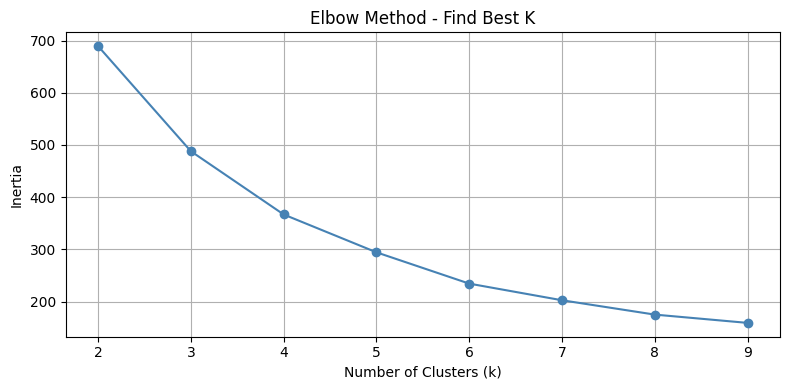

In [163]:
inertia = []
k_range = range(2, 10)

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    km.fit(X)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_range, inertia, marker='o', color='steelblue')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method - Find Best K')
plt.xticks(k_range)
plt.grid(True)
plt.tight_layout()
plt.show()

In [164]:
km = KMeans(n_clusters=4, init='k-means++', random_state=42, n_init=10)
customer_df['cluster'] = km.fit_predict(X)

print(customer_df['cluster'].value_counts())

cluster
1    138
3     75
0     55
2     29
Name: count, dtype: int64


To group customers into meaningful segments based on their purchasing behaviour, K-Means clustering was applied using key features including purchase frequency, total spent, median gap days, and current gap days.

The clustering revealed four distinct customer segments. The largest group is **Loyal Customers (138 customers, 46.5%)**, representing the backbone of the business. These customers purchase consistently and remain within their expected cycle.

**At-Risk Customers (75 customers, 25.3%)** show early signs of disengagement. They have exceeded their normal purchasing window and require attention to prevent further loss.

**High Value Customers (55 customers, 18.5%)** represent the most commercially important segment. They are characterized by higher spending and frequent purchases, making them a key focus for retention.

Finally, **Lost Customers (29 customers, 9.8%)** have gone significantly beyond their expected return window and are likely no longer active.

In [165]:
cluster_profile = customer_df.groupby('cluster').agg(
    customer_count=('customer_id', 'count'),
    avg_frequency=('frequency', 'mean'),
    avg_total_spent=('total_spent', 'mean'),
    avg_median_gap=('median_gap_days', 'mean'),
    avg_current_gap=('current_gap_days', 'mean')
).round(1)

print(cluster_profile)

         customer_count  avg_frequency  avg_total_spent  avg_median_gap  \
cluster                                                                   
0                    55           11.2           8419.0            29.1   
1                   138            5.6           3297.6            58.5   
2                    29            1.3            751.5            57.7   
3                    75            2.8           1546.2           112.5   

         avg_current_gap  
cluster                   
0                   29.0  
1                   56.0  
2                  302.8  
3                  131.8  


In [166]:
print(customer_df.groupby(['cluster', 'status']).size().unstack(fill_value=0))

status   active  at risk  churned  due soon  one-time - churned
cluster                                                        
0            34        5        8         8                   0
1            81       19       19        18                   1
2             0        0        4         0                  25
3            32       20       10        13                   0


In [167]:
cluster_labels = {
    0: 'High Value',
    1: 'Loyal Customers',
    2: 'Lost Customers',
    3: 'At-Risk Customers'
}

customer_df['cluster_label'] = customer_df['cluster'].map(cluster_labels)

print(customer_df[['customer_id', 'cluster_label', 'status',
                    'frequency', 'total_spent',
                    'median_gap_days', 'current_gap_days']].head(10))

   customer_id      cluster_label              status  frequency  total_spent  \
0      1044891    Loyal Customers            due soon          6      1565.02   
1      1047572  At-Risk Customers             at risk          2       425.37   
2      1098919    Loyal Customers              active          6      3104.61   
3      1157662     Lost Customers  one-time - churned          1        20.65   
4      1279121     Lost Customers  one-time - churned          1      1698.00   
5      1432519         High Value              active         13     12411.14   
6      1440972  At-Risk Customers             at risk          3       767.45   
7      1447065  At-Risk Customers              active          2       299.76   
8      1447451    Loyal Customers              active          7      1415.22   
9      1454696    Loyal Customers              active          6      5982.51   

   median_gap_days  current_gap_days  
0             51.0                62  
1             83.0            

In [168]:
print(customer_df['cluster_label'].value_counts())

cluster_label
Loyal Customers      138
At-Risk Customers     75
High Value            55
Lost Customers        29
Name: count, dtype: int64


In [169]:
customer_df["gap_to_use"] = customer_df["median_gap_days"].fillna(global_median)

customer_df["expected_next_purchase"] = (
    customer_df["last_purchase"] +
    pd.to_timedelta(customer_df["gap_to_use"], unit="D")
)


In [170]:
customer_df.head()

,customer_id,name,email,first_purchase,last_purchase,frequency,total_spent,median_gap_days,current_gap_days,status,cluster,cluster_label,gap_to_use,expected_next_purchase
0,1044891,Vikram Chavez,vchavez671@live.com,2024-02-22,2024-10-30,6,1565.02,51.0,62,due soon,1,Loyal Customers,51.0,2024-12-20
1,1047572,Patrick Nelson,patrick_nelson@outlook.com,2024-05-10,2024-08-01,2,425.37,83.0,152,at risk,3,At-Risk Customers,83.0,2024-10-23
2,1098919,Hiroshi Gray,gray.h@comcast.net,2024-01-31,2024-12-21,6,3104.61,55.0,10,active,1,Loyal Customers,55.0,2025-02-14
3,1157662,Olivia Watson,owatson@att.net,2024-01-08,2024-01-08,1,20.65,57.0,358,one-time - churned,2,Lost Customers,57.0,2024-03-05
4,1279121,Takeshi Foster,foster.t@yahoo.com,2024-02-20,2024-02-20,1,1698.00,57.0,315,one-time - churned,2,Lost Customers,57.0,2024-04-17


Having predicted each customer's expected next purchase date and successfully clustered the customer base into four distinct segments, the following recommendations to help the business maximise revenue and strengthen customer relationships.

Since the expected next purchase date is now known for every customer, the business should schedule targeted marketing emails to be sent one week before each customer is due, ensuring communication reaches them at precisely the moment they are most likely to be considering a refill. 

The content of each email should be tailored according to the customer's cluster segment as follows:
High Value Customers (55 customers) should receive premium communications that acknowledge their loyalty and reinforce the value of staying with the business. Losing a single customer from this group represents a disproportionate revenue loss and therefore retention of this segment should be the highest priority.


Loyal Customers (138 customers) should receive warm and appreciative messages with gentle reminders of their upcoming refill window to keep their purchasing cycle uninterrupted.


At-Risk Customers (75 customers) require an urgent and incentive-led approach. A well-timed email offering a compelling reason to return could recover a significant portion of this group before they transition into full churn.


Lost Customers (29 customers) should be targeted with a re-engagement campaign presenting a strong reason to return, given that they have gone well beyond their expected purchasing window.


Finally, the business should move away from its current unstructured discount strategy, which was shown to have no measurable impact on purchase volume or revenue, and redirect that investment into this personalised, time-based communication approach that aligns with each customer's natural buying rhythm.